Training K-Means...
Training Agglomerative Clustering...
Training DBSCAN...

Report: Performance of Unsupervised Learning Algorithms
                  Algorithm  Silhouette Score  Adjusted Rand Index  \
0                   K-Means            0.7916               0.9973   
1  Agglomerative Clustering            0.7916               0.9973   
2                    DBSCAN            0.4972               0.9074   

   Calinski-Harabasz Score  
0               11066.9713  
1               11066.9713  
2                2012.0724  


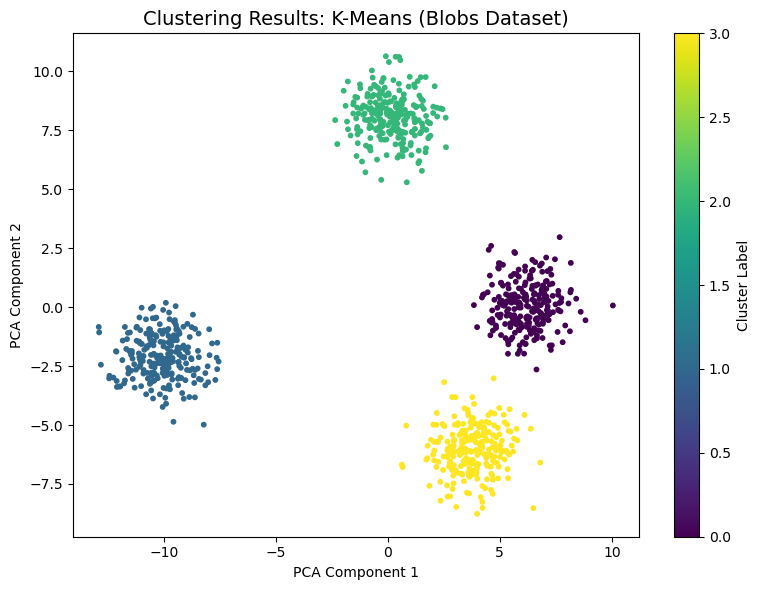

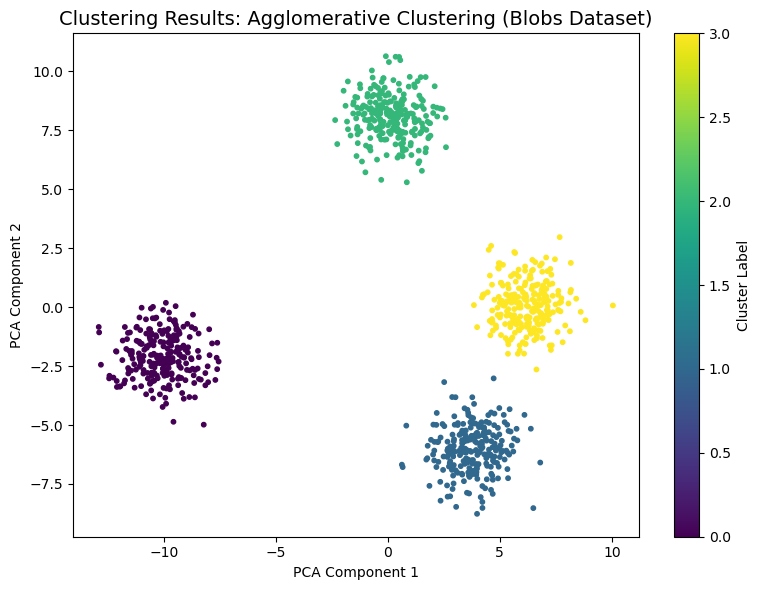

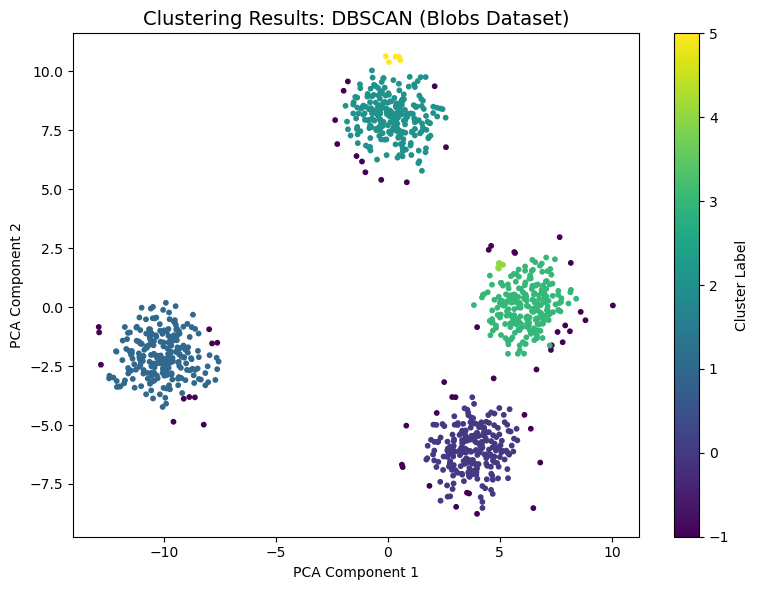

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# Function to load or generate dataset
def load_data(dataset_name="blobs"):
    if dataset_name == "blobs":
        X, y_true = make_blobs(n_samples=1000, n_features=2, centers=4, cluster_std=1.0, random_state=42)
    elif dataset_name == "iris":
        data = load_iris()
        X, y_true = data.data, data.target
    else:
        raise ValueError("Unsupported dataset! Choose 'blobs' or 'iris'.")
    return X, y_true

# Load dataset
dataset_name = "blobs"  # Change to "iris" for the Iris dataset
X, y_true = load_data(dataset_name)

# Define clustering algorithms
algorithms = {
    'K-Means': KMeans(n_clusters=4, random_state=42),
    'Agglomerative Clustering': AgglomerativeClustering(n_clusters=4),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
}

# Dictionary to store results
results = []

# Evaluate each algorithm
for name, model in algorithms.items():
    print(f"Training {name}...")
    if hasattr(model, 'fit_predict'):
        y_pred = model.fit_predict(X)
    else:
        model.fit(X)
        y_pred = model.labels_

    # Compute evaluation metrics
    silhouette = silhouette_score(X, y_pred) if len(set(y_pred)) > 1 else -1
    ari = adjusted_rand_score(y_true, y_pred)
    calinski_harabasz = calinski_harabasz_score(X, y_pred) if len(set(y_pred)) > 1 else -1

    # Append results
    results.append({
        'Algorithm': name,
        'Silhouette Score': round(silhouette, 4),
        'Adjusted Rand Index': round(ari, 4),
        'Calinski-Harabasz Score': round(calinski_harabasz, 4)
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the report
print("\nReport: Performance of Unsupervised Learning Algorithms")
print(results_df)

# Export report to a CSV file
results_df.to_csv(f"{dataset_name}_clustering_report.csv", index=False)

# Visualize clustering results using PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

for name, model in algorithms.items():
    if hasattr(model, 'fit_predict'):
        y_pred = model.fit_predict(X)
    else:
        model.fit(X)
        y_pred = model.labels_

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='viridis', s=10)
    plt.title(f"Clustering Results: {name} ({dataset_name.capitalize()} Dataset)", fontsize=14)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.savefig(f"{name}_clustering_{dataset_name}.png")
    plt.show()
